<a href="https://colab.research.google.com/github/ob3x/Learn-Ds/blob/main/Analiza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import sklearn

In [41]:
df_raw = pd.read_csv("Employe_Performance_dataset.csv")
df = df_raw.copy()
df.head()

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
1,2,Timothy Sanchez,25,Other,Sales,4249,2020-11-09,2.0,11,Inactive,Los Angeles,Evening
2,3,Chad Nichols,57,Other,Sales,3058,2019-02-12,NaN,1,Inactive,New York,Morning
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
4,5,Amber Harris,35,Other,IT,4317,2020-02-15,5.0,16,Inactive,New York,Evening


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 1000 non-null   int64  
 1   Name               1000 non-null   object 
 2   Age                1000 non-null   int64  
 3   Gender             1000 non-null   object 
 4   Department         1000 non-null   object 
 5   Salary             1000 non-null   int64  
 6   Joining Date       1000 non-null   object 
 7   Performance Score  502 non-null    float64
 8   Experience         1000 non-null   int64  
 9   Status             1000 non-null   object 
 10  Location           1000 non-null   object 
 11  Session            1000 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 93.9+ KB


In [43]:
for col in ["Performance Score", "Status", "Location", "Name", "ID", "Joining Date", "Session"]:
  df = df.drop(columns=[col])


In [44]:
for col in ["Gender", "Department"]:
  df[col] = df[col].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Age         1000 non-null   int64   
 1   Gender      1000 non-null   category
 2   Department  1000 non-null   category
 3   Salary      1000 non-null   int64   
 4   Experience  1000 non-null   int64   
dtypes: category(2), int64(3)
memory usage: 25.8 KB


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["Age", "Experience"]] = scaler.fit_transform(df[["Age", "Experience"]])
df.head()

,Age,Gender,Department,Salary,Experience
0,0.511269,Female,HR,5641,1.029622
1,-1.117879,Other,Sales,4249,0.154093
2,1.148762,Other,Sales,3058,-1.596965
3,1.219595,Female,IT,5895,0.504305
4,-0.409554,Other,IT,4317,1.029622


In [59]:
x = df.drop(columns=["Salary"])
y = df["Salary"]

x = pd.get_dummies(x, drop_first=True, columns=["Gender", "Department"], dtype=int)
x.head()

,Age,Experience,Gender_Male,Gender_Other,Department_IT,Department_Sales
0,0.511269,1.029622,0,0,0,0
1,-1.117879,0.154093,0,1,0,1
2,1.148762,-1.596965,0,1,0,1
3,1.219595,0.504305,0,0,1,0
4,-0.409554,1.029622,0,1,1,0


In [61]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"x_train: {x_train.shape}")
print(f"x_test: {x_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

x_train: (800, 6)
x_test: (200, 6)
y_train: (800,)
y_test: (200,)


,Salary
521,2302
737,2797
740,8189
660,8150
411,3739
...,...
408,5092
332,6259
208,2223
613,5152


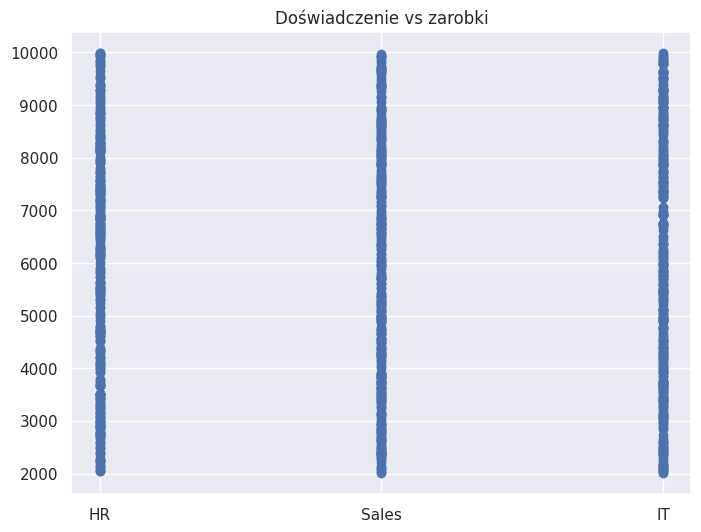

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

plt.figure(figsize=(8, 6))
plt.title("Doświadczenie vs zarobki")
plt.scatter(df["Department"], y)